<a href="https://colab.research.google.com/github/zaraaa12/BigData/blob/main/SmartShopper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    Tokenizer, StopWordsRemover, CountVectorizer, IDF,
    StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
)
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import when, regexp_replace, col
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [ ]:
# Inisialisasi SparkSession
spark = SparkSession.builder \
    .appName("LaptopClassification") \
    .getOrCreate()

df = spark.read.csv("/content/data_cleaned.csv", header=True, inferSchema=True)
df.show(5)

+-------+--------------------+--------+------------------+-----+
|  Brand|         Description|   Price|            Rating| Sold|
+-------+--------------------+--------+------------------+-----+
|   ASUS|\ROG Ally - 7""\"...|    NULL|              NULL| NULL|
|Smatree|Hard EVA Protecti...| $45.99 |4.6 out of 5 stars|  560|
|Smatree|Heavy Duty Hard S...| $99.99 |4.7 out of 5 stars|   77|
|   ASUS|\ROG Zephyrus 202...|    NULL|              NULL| NULL|
|   ASUS|ROG Strix 850W Go...|$184.99 |4.7 out of 5 stars|3,872|
+-------+--------------------+--------+------------------+-----+
only showing top 5 rows



In [ ]:
#Bersihkan data kosong
df = df.filter(
    df.Brand.isNotNull() & (df.Brand != "") &
    df.Price.isNotNull() &
    df.Rating.isNotNull()
)

In [ ]:
df = df.withColumn("Price", regexp_replace("Price", "[$,]", "").cast("double"))
df = df.withColumn("Rating", regexp_replace("Rating", " out of 5 stars", "").cast("double"))
df = df.withColumn("Sold", regexp_replace("Sold", ",", "").cast("int"))

In [ ]:
df.show(100)

+----------+--------------------+------+------+----+
|     Brand|         Description| Price|Rating|Sold|
+----------+--------------------+------+------+----+
|   Smatree|Hard EVA Protecti...| 45.99|   4.6| 560|
|   Smatree|Heavy Duty Hard S...| 99.99|   4.7|  77|
|      ASUS|ROG Strix 850W Go...|184.99|   4.7|3872|
| GravaStar|Wireless Gaming M...| 99.95|   4.3| 428|
|      ASUS|ROG Strix 26.5” 1...| 669.0|   4.5| 534|
|      ASUS|TUF Gaming A15 Ga...|694.68|   4.3| 369|
|Skullcandy|Method 360 ANC Wi...| 99.99|   4.3| 365|
|      ASUS|ROG Keris Lightwe...| 39.99|   4.5|  55|
|      ASUS|ROG Falchion Wire...|149.99|   4.4| 219|
|      ASUS|\ROG Zephyrus G16...|150.88|   0.0|   0|
|      ASUS|\ROG Zephyrus G16...| 29.99|   4.7| 487|
|      ASUS|ROG Strix Scope R...|  69.0|   4.6| 741|
|  Motorola|Edge+ | 2023 | Un...|399.99|   4.4| 851|
|MINISFORUM|UM880 Plus Mini P...|518.99|   4.4|  32|
|      ASUS|ROG Strix GeForce...|429.99|   4.7|3105|
|      ASUS|ROG STRIX X870-I ...|448.99|   4.3

In [ ]:
# Label klasifikasi berdasarkan kolom terjual
from pyspark.sql.functions import when

df = df.withColumn(
    "label",
    when((df.Sold > 500) & (df.Rating > 4), 1).otherwise(0)
)

In [ ]:
tokenizer = Tokenizer(inputCol="Brand", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
vectorizer = CountVectorizer(inputCol="filtered_words", outputCol="rawFeatures")
idf = IDF(inputCol="rawFeatures", outputCol="brand_features")

In [ ]:
rating_indexer = StringIndexer(inputCol="Rating", outputCol="rating_index", handleInvalid="keep")
rating_encoder = OneHotEncoder(inputCol="rating_index", outputCol="rating_encoded")

In [ ]:
#Scaling
price_assembler = VectorAssembler(inputCols=["Price"], outputCol="price_vec")
price_scaler = StandardScaler(inputCol="price_vec", outputCol="price_scaled")

In [ ]:
feature_assembler = VectorAssembler(
    inputCols=["brand_features", "rating_encoded", "price_scaled"],
    outputCol="features"
)

In [ ]:
#Model klasifikasi RandomForest
classifier = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)

In [ ]:
pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    vectorizer,
    idf,
    rating_indexer,
    rating_encoder,
    price_assembler,
    price_scaler,
    feature_assembler,
    classifier
])

In [ ]:
# train-test split
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

# train model
model = pipeline.fit(train_df)

predictions = model.transform(test_df)

In [ ]:
#Evaluasi akurasi
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {accuracy}")

Accuracy: 0.42857142857142855


In [ ]:
#Classification

predictions = predictions.withColumn(
    "label_name",
    when(predictions.label == 1, "Worth it").otherwise("Not Worth it")
)

predictions = predictions.withColumn(
    "predicted_label_name",
    when(predictions.prediction == 1, "Worth it").otherwise("Not Worth it")
)

predictions.select(
    "Brand", "Description", "Price", "Rating", "Sold",
    "label_name", "predicted_label_name", "prediction"
).show(100, truncate=False)

+---------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+------+----+------------+--------------------+----------+
|Brand    |Description                                                                                                                                                                                        |Price |Rating|Sold|label_name  |predicted_label_name|prediction|
+---------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+------+----+------------+--------------------+----------+
|ASUS     |ROG Azoth 75 Wireless DIY Custom Gaming Keyboard, OLED Display, Gasket-Mount, Three-Layer Dampening, Hot-Swappable Pre-lubed ROG NX Snow Switches & Keyboard Stabilizers, PBT

In [ ]:
pandas_df = predictions.select("label_name", "prediction").toPandas()
print(pandas_df['label_name'].unique())

['Worth it' 'Not Worth it']


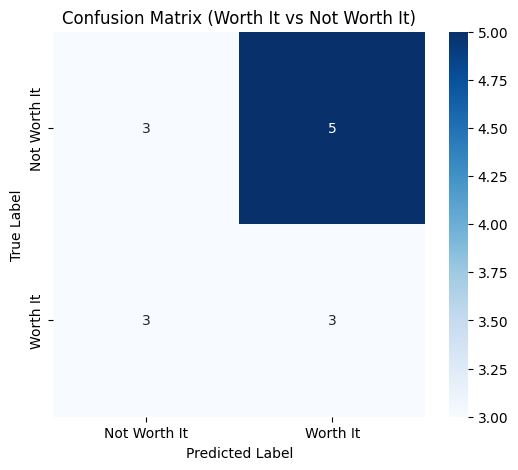

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Konversi DataFrame PySpark ke Pandas
pandas_df = predictions.select("label_name", "prediction").toPandas()

# Mapping numeric prediction ke label string (pastikan sesuai)
pandas_df['prediction'] = pandas_df['prediction'].apply(lambda x: 'Worth It' if x == 1 else 'Not Worth It')

# Normalisasi kapitalisasi
pandas_df['label_name'] = pandas_df['label_name'].str.strip().str.title()
pandas_df['prediction'] = pandas_df['prediction'].str.strip().str.title()
# Buat confusion matrix
labels = ['Not Worth It', 'Worth It']
cm = confusion_matrix(pandas_df['label_name'], pandas_df['prediction'], labels=labels)

# Visualisasi
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Not Worth It', 'Worth It'],
            yticklabels=['Not Worth It', 'Worth It'],
            cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Worth It vs Not Worth It)")
plt.show()

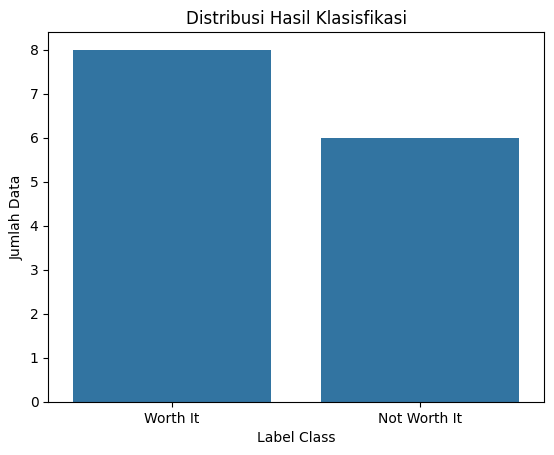

In [ ]:
sns.countplot(x="prediction", data=pandas_df)
plt.title("Distribusi Hasil Klasisfikasi")
plt.xlabel("Label Class")
plt.ylabel("Jumlah Data")
plt.show()

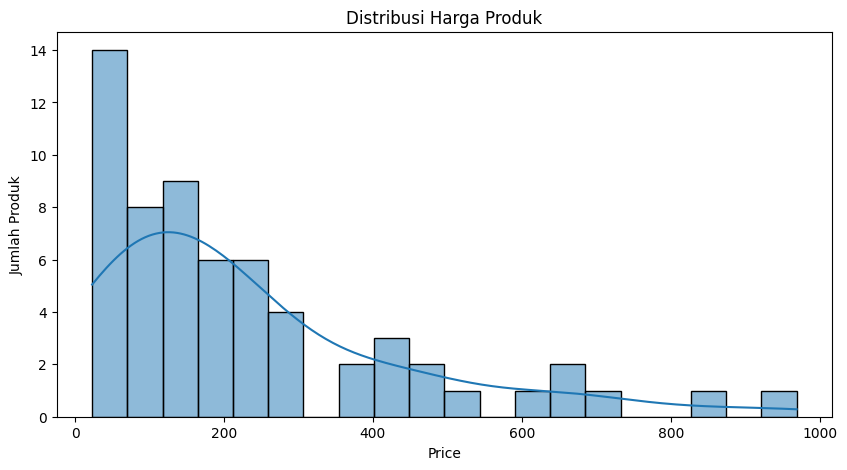

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df.select('Price').toPandas()['Price'], bins=20, kde=True)
plt.title('Distribusi Harga Produk')
plt.xlabel('Price')
plt.ylabel('Jumlah Produk')
plt.show()

In [ ]:
save = predictions.select("Brand", "Description", "Price","Rating", "Sold", "label_name", "prediction")
save.write.csv("prediction.csv", header=True)